In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("MLB Games.csv")

# Preview data
print(df.head())
print(df.info())

       date  season  neutral  ... rating2_post score1 score2
0  26-09-19    2019        0  ...  1503.865793      6      3
1  25-09-19    2019        0  ...  1504.979987      5      2
2  24-09-19    2019        0  ...  1506.268187      6      5
3  24-09-19    2019        0  ...  1507.063210      4      1
4  23-09-19    2019        0  ...  1508.460780      7      2

[5 rows x 26 columns]
<class 'pandas.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1236 non-null   str    
 1   season        1236 non-null   int64  
 2   neutral       1236 non-null   int64  
 3   playoff       21 non-null     str    
 4   team1         1236 non-null   str    
 5   team2         1236 non-null   str    
 6   elo1_pre      1236 non-null   float64
 7   elo2_pre      1236 non-null   float64
 8   elo_prob1     1236 non-null   float64
 9   elo_prob2     1236 non-null   float64

In [3]:
# Drop rows with missing values (simple approach)
df = df.dropna()

# Show columns
print(df.columns)

Index(['date', 'season', 'neutral', 'playoff', 'team1', 'team2', 'elo1_pre',
       'elo2_pre', 'elo_prob1', 'elo_prob2', 'elo1_post', 'elo2_post',
       'rating1_pre', 'rating2_pre', 'pitcher1', 'pitcher2', 'pitcher1_rgs',
       'pitcher2_rgs', 'pitcher1_adj', 'pitcher2_adj', 'rating_prob1',
       'rating_prob2', 'rating1_post', 'rating2_post', 'score1', 'score2'],
      dtype='str')


In [4]:
target_column = "Result"   # change if needed

In [5]:
label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [7]:
print(df.columns.tolist())
print(target_column in df.columns)

['date', 'season', 'neutral', 'playoff', 'team1', 'team2', 'elo1_pre', 'elo2_pre', 'elo_prob1', 'elo_prob2', 'elo1_post', 'elo2_post', 'rating1_pre', 'rating2_pre', 'pitcher1', 'pitcher2', 'pitcher1_rgs', 'pitcher2_rgs', 'pitcher1_adj', 'pitcher2_adj', 'rating_prob1', 'rating_prob2', 'rating1_post', 'rating2_post', 'score1', 'score2']
False


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ----------------------------
# 1. Create target (who won)
# ----------------------------
df["winner"] = (df["score1"] > df["score2"]).astype(int)

# ----------------------------
# 2. Define features and target
# ----------------------------
X = df.drop(["score1", "score2", "winner"], axis=1)
y = df["winner"]

# ----------------------------
# 3. Encode categorical columns
# ----------------------------
X = pd.get_dummies(X)

# ----------------------------
# 4. Train/test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 5. Train model
# ----------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# ----------------------------
# 6. Predict
# ----------------------------
rf_preds = rf_model.predict(X_test)

# ----------------------------
# 7. Evaluate
# ----------------------------
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.4

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.00      0.00      0.00         2

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5



In [13]:
et_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

et_model.fit(X_train, y_train)

et_preds = et_model.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, et_preds))
print("\nClassification Report:\n", classification_report(y_test, et_preds))

Extra Trees Accuracy: 0.6

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.50      0.50      0.50         2

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



In [14]:
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

print("\nExtra Trees Confusion Matrix:")
print(confusion_matrix(y_test, et_preds))

Random Forest Confusion Matrix:
[[2 1]
 [2 0]]

Extra Trees Confusion Matrix:
[[2 1]
 [1 1]]


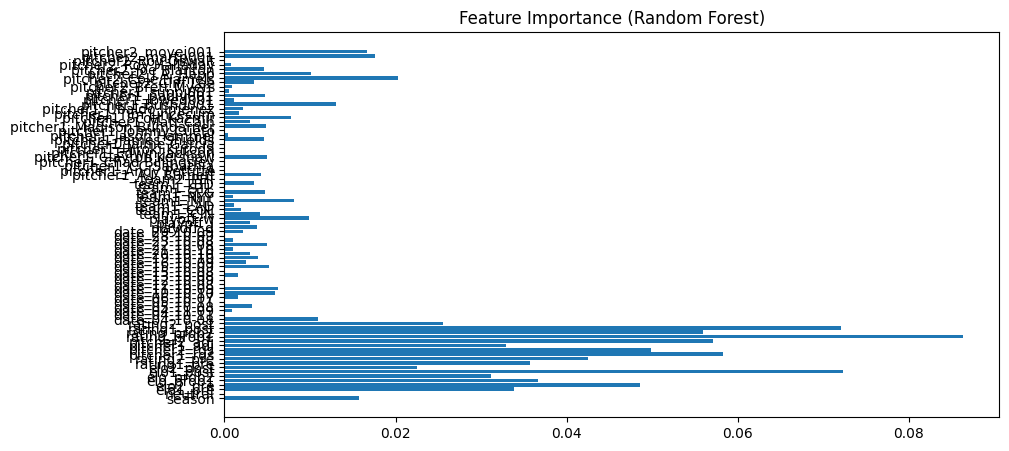

In [15]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()